# Imports der Bibliotheken

In [1]:
#Masterprojekt SFH - 1 Verbraucher, 1 Wärmepumpe, 1 Speicher
import logging
logger = logging.getLogger("gurobipy")
logger.propagate = False

import pandas as pd
import pypsaheat as ph
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Einlesen Lastgänge & Zuordnung der Daten

In [2]:
#Einlesen der Lastgänge
input_data = pd.read_csv('Inputs/MasterProjekt_Lastprofile.csv', index_col=0)
input_data

#limitieren der Daten auf 3 Wochen
start = 0      # 0 = Anfang des Jahres
input_data = input_data.iloc[start : start + 504]
input_data.index = range(len(input_data)) 

In [3]:
input_data = input_data.drop(columns=["Waerme gesamt (kW)"]).rename(
    columns={"Temp C": "temp","Zone 2-Trinkwarmwasser (kW)": "heat_water","Zone 2-Raumwaerme (kW)": "heat_space",}
)
input_data["electricity"] = 0.000
input_data["PV"] = 0.000
input_data = input_data[["electricity", "PV", "temp", "heat_water", "heat_space"]]
input_data.index.name = "index"
input_data
input_data.to_csv("Inputs/load_profile_3_weeks.csv", index=True)

<Axes: xlabel='index'>

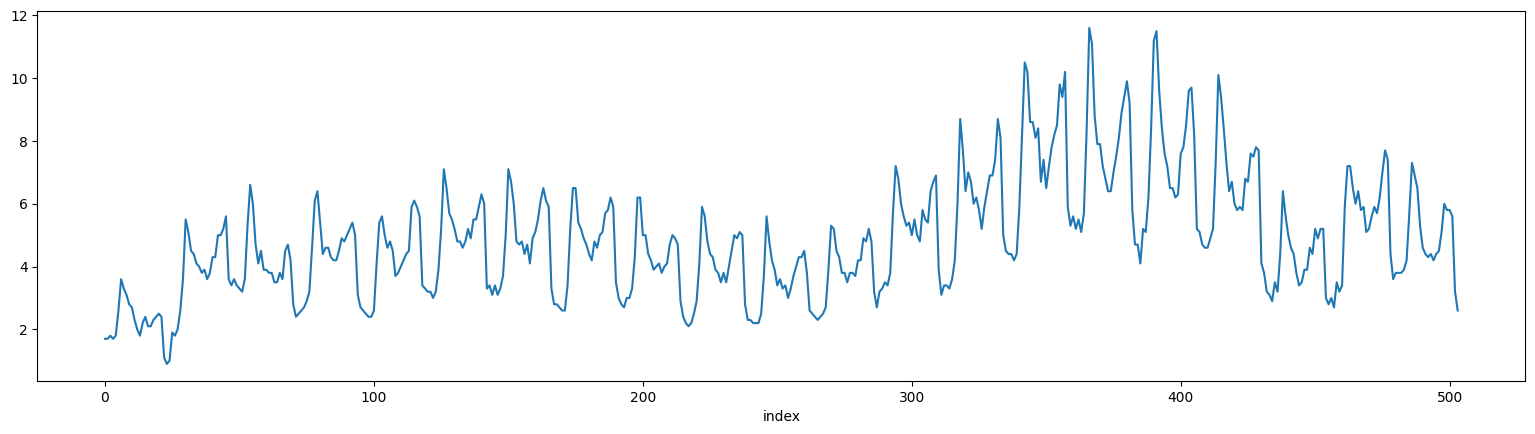

In [4]:
#Zuordnung der Daten aus den Lastgängen
raumwaerme = input_data['heat_space'] #Heizlast von SFH in kW
raumwaerme.plot(figsize=(19.2, 4.8))

<Axes: xlabel='index'>

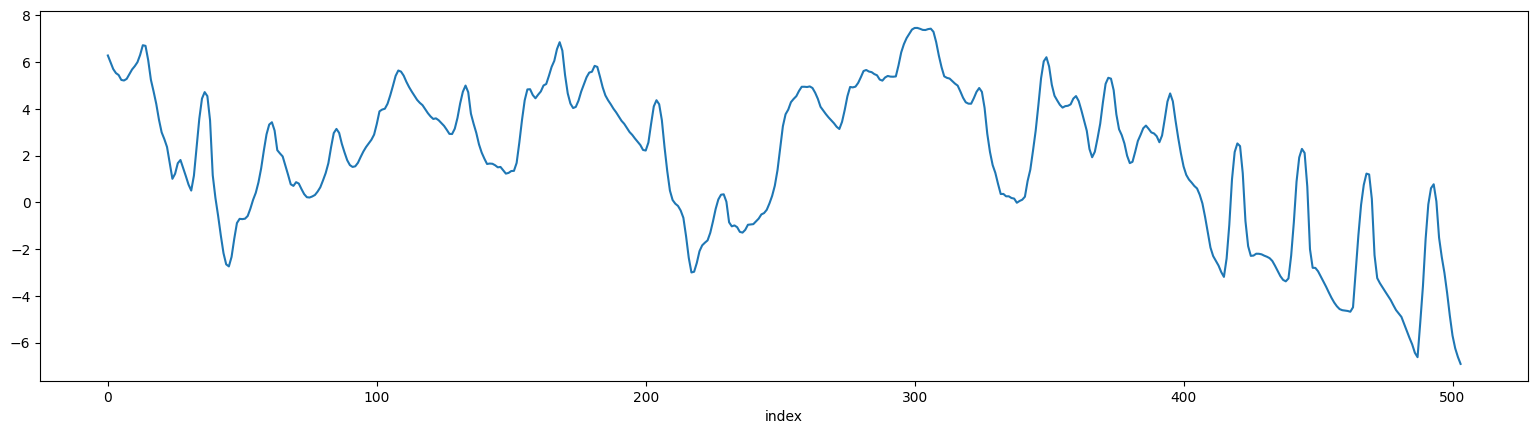

In [5]:
# aussentemperatur = df_data_weather['DE_temperature']
aussentemperatur = input_data['temp']
aussentemperatur.plot(figsize=(19.2, 4.8))

# System Eigenschaften

In [6]:
#Wärmespeicher Eigenschaften 
Store_height = 2 #m
Store_base = 0.8 #m²
Store_layer = 3

T_Warmwasser = 55

#Wärmepumpen Leistung
HP_power = 20 #kW Wärmepumpenleistung

#Strom
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug
grid_power = np.inf #kW Hausanschluss Leistung

<Axes: xlabel='index'>

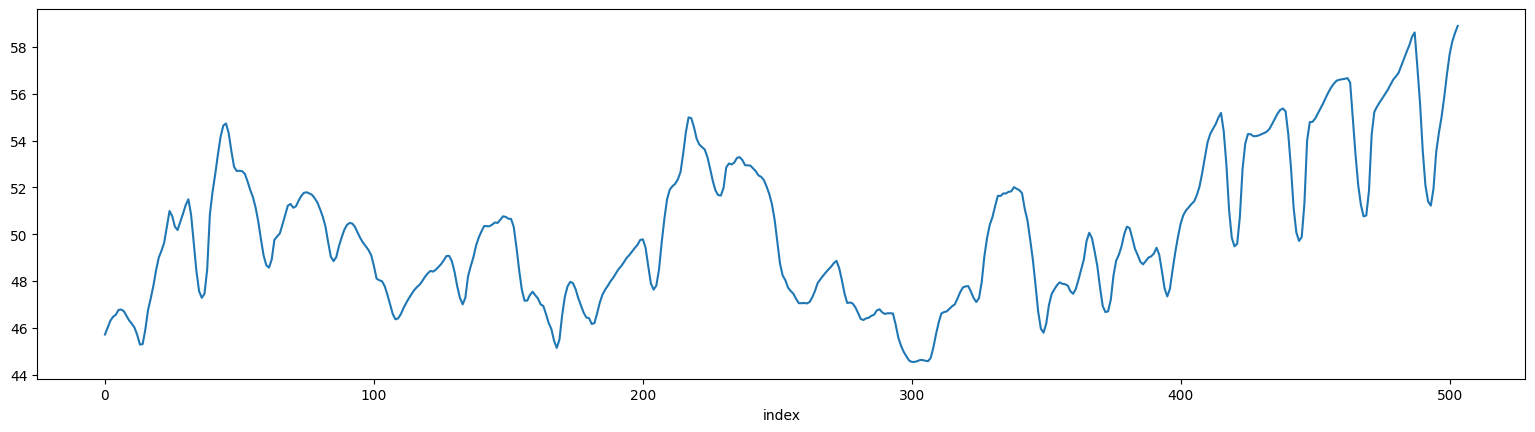

In [7]:
# Vorlauftemperatur für Heizsystem
T_at_0 = 52  #°C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  #°C/°C Steigung der Heizkurve

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur)
T_flow.plot(figsize=(19.2, 4.8))

# Modellerstellung

In [8]:
# Aufbau des Modells
n = ph.HeatNetwork()

n.set_snapshots(input_data.index)

n.add("Bus",  
      name = "electricity"      
)

n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
  )

n.add('Load', 
      bus = 'electricity', 
      name = 'Elektrische Last',
      #p_set = power_demand_hp
)

# Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = raumwaerme,
      T_demand = T_flow
      )

# Hinzufügen eines Schichtspeichers mit konstanten Volumschichten
n.add('HeatStore',
      name='hs',
      constant='volume',
      height=Store_height,
      base=Store_base,
      N_layer=Store_layer,       
      cyclic=False,
      U_wall=0,                 
      T_initial=[55, 50, 45]     # numerische Liste (Länge = N_layer) oder single float
)

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp1',
      bus0 = 'electricity',
      p_nom = HP_power,          # Nennleistung (thermal kW)
      m_nom = 700, # kg/h 
      heat_store = 'hs',
      T_source = aussentemperatur,
      T_nom = 65,
      heat_source  = 'air'
      )

#Hinzufügen der Warmwasserlast
# n.add('HeatLoad',
#       name = 'heat_water_demand',
#       heat_store = 'hs',
#       p_set = input_data['DE_heat_profile_water_SFH']/1000,
#       T_demand = T_Warmwasser
#       )

In [9]:
n.heat_loads

attribute,heat_store,carrier,type,p_set,T_demand,T_diff_return,internal_exchange,outlet_height,inlet_height
HeatLoad,,,,,,,,,
heat_space_demand,hs,,,0.0,50.0,10.0,False,1.0,0.0


# Optimierung

In [10]:
# Optimierung mit rollierendem Horizont
n.optimize.optimize_with_rolling_horizon(horizon = 24, overlap = 12)

INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [0:23] (1/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2733977
Academic license - for non-commercial use only - expires 2026-11-06


INFO:linopy.io: Writing time: 0.05s


Read LP format model from file C:\Users\Christian\AppData\Local\Temp\linopy-problem-q9xoau0h.lp
Reading time = 0.01 seconds
obj: 672 rows, 216 columns, 1557 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5700X3D 8-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 672 rows, 216 columns and 1557 nonzeros
Model fingerprint: 0xdd3cbf8f
Variable types: 192 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [7e-04, 1e+02]
  Objective range  [3e-01, 3e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e-01, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 312 rows and 48 columns
Presolve time: 0.00s
Presolved: 360 rows, 168 columns, 1125 nonzeros
Variable types: 144 continuous, 24 integer (24 binary)

Root rela

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 216 primals, 0 duals
Objective: 8.90e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [12:35] (2/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


...

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 216 primals, 0 duals
Objective: 2.61e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [492:503] (42/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2733977
Academic license - for non-commercial use only - expires 2026-11-06


INFO:linopy.io: Writing time: 0.04s


Read LP format model from file C:\Users\Christian\AppData\Local\Temp\linopy-problem-x9jn63ao.lp
Reading time = 0.01 seconds
obj: 336 rows, 108 columns, 777 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5700X3D 8-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 336 rows, 108 columns and 777 nonzeros
Model fingerprint: 0x0d1a4460
Variable types: 96 continuous, 12 integer (12 binary)
Coefficient statistics:
  Matrix range     [7e-04, 1e+02]
  Objective range  [3e-01, 3e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 156 rows and 24 columns
Presolve time: 0.00s
Presolved: 180 rows, 84 columns, 561 nonzeros
Variable types: 72 continuous, 12 integer (12 binary)

Root relaxation

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 108 primals, 0 duals
Objective: 1.34e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.


In [11]:
#Zuordnung der Ergebnisse
m = n.optimize.create_model()

Index(['electricity'], dtype='object', name='Bus')


In [12]:
#Inhalte der Optimierung
m

Linopy MILP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * HeatStore-hs-T_layer (snapshot, layer)
 * HeatPump-status (snapshot, HeatPump)
 * HeatPump-hp1-T_supply (snapshot, HeatPump)
 * HeatPump-hp1-T_bin_layer_hs (snapshot, layer)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * HeatStore-hs-layer_balance (snapshot, layer)
 * HeatStore-hs-max_layer_temp (snapshot, layer)
 * HeatStore-hs-only_one_hp_active (snapshot)
 * HeatPump-hp1-max_T_bin_layer_hs (HeatPump, snapshot, layer)
 * HeatPump-hp1-min_T_bin_layer_hs (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_bin_layer_eq_T_layer_hs_max (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_bin_layer_eq_T_layer_hs_min (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_supply_status (snapshot, HeatPump)
 * HeatPump-hp1-p_heat_lower (layer, snapshot, HeatPump)
 * HeatPump-hp1-p_heat_upper (layer, snapshot, HeatP

In [13]:
n.heat_pumps_t

{'T_source':             hp1
 snapshot       
 0         6.286
 1         5.997
 2         5.705
 3         5.534
 4         5.451
 ...         ...
 499      -4.842
 500      -5.690
 501      -6.235
 502      -6.605
 503      -6.903
 
 [504 rows x 1 columns],
 'T_nom': HeatPump   hp1
 snapshot      
 0         65.0
 1         65.0
 2         65.0
 3         65.0
 4         65.0
 ...        ...
 499       65.0
 500       65.0
 501       65.0
 502       65.0
 503       65.0
 
 [504 rows x 1 columns],
 'p_min_pu': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'p_max_pu': Empty Data

In [14]:
heatstore_daten=n.heat_stores_t.T

# Python Ergebnisse

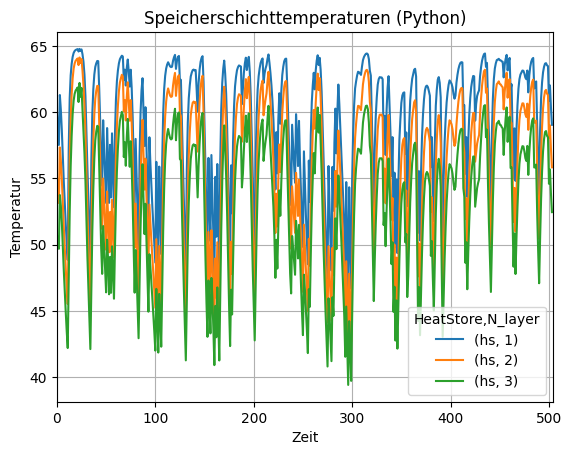

In [15]:
n.heat_stores_t.T.plot()
plt.title('Speicherschichttemperaturen (Python)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 504)
plt.grid()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/py_speicherschichten - 3 Wochen.png')
plt.show()


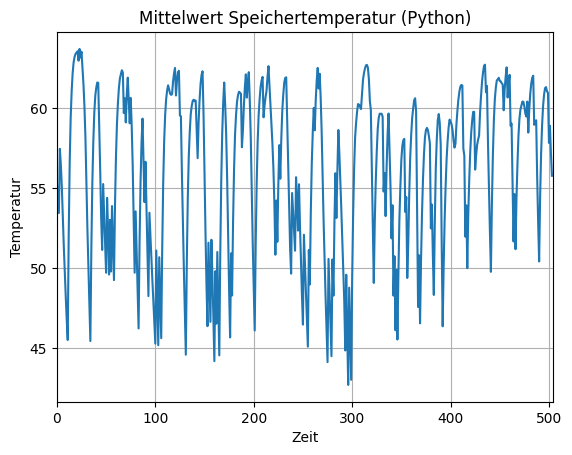

In [16]:
#Zuordnung der Ergebnisse aus dem Modell
#WP-Daten 
p_elec = n.heat_pumps_t.p_elec
p_heat = n.heat_pumps_t.p_heat
m_flow = n.heat_pumps_t.m_flow
COP = n.heat_pumps_t.COP
status = n.heat_pumps_t.status

#Mitteltemperatur der Schichten
hs_m = heatstore_daten['hs'].mean(axis=1)
hs_m.plot()
plt.title('Mittelwert Speichertemperatur (Python)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 504)
plt.grid()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/py_speicherschichten_m - 3 Wochen.png')
plt.show()

In [17]:
# Berechnung der Kosten für den Netzbezug durch die Wärmepumpe
cost_grid = p_elec * grid_cost
total_cost_grid = cost_grid.sum().sum()

print(f"Kosten Netzbezug durch WP: {total_cost_grid:.2f} €")

Kosten Netzbezug durch WP: 506.92 €


# TRNSYS Ergebnisse

In [18]:
TRNSYSinputs = [
    "Inputs/TRNSYS/3weeks/TRNSYSMassenstromHausseitig3weeks.csv",
    "Inputs/TRNSYS/3weeks/TRNSYSRaumwärmebedarf3weeks.csv",
    "Inputs/TRNSYS/3weeks/TRNSYSRücklauftemperatur3weeks.csv",
    "Inputs/TRNSYS/3weeks/TRNSYSspeichermitteltemperatur3weeks.csv",
    "Inputs/TRNSYS/3weeks/TRNSYSspeicherschichttemperaturen3weeks.csv",
    "Inputs/TRNSYS/3weeks/TRNSYSWärmepumpe3weeks.csv"
]

df_liste = []

for f in TRNSYSinputs:
    df = pd.read_csv(f, encoding='latin1', skipinitialspace=True, engine='python', quoting=3, sep=',')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    if 'TIME' in df.columns:
        df = df[pd.to_numeric(df['TIME'], errors='coerce').notnull()]
        df = df.apply(pd.to_numeric, errors='coerce')
        df['TIME'] = df['TIME'].round(2)
        df = df.set_index('TIME')
    
    df_liste.append(df)

TRNSYSdata3weeks = pd.concat(df_liste, axis=1).sort_index().reset_index()
TRNSYSdata3weeks = TRNSYSdata3weeks.rename(columns={'TIME':'Time', 'Massenstrom':'ts_m_heatspace', 'T_amb':'ts_T_amb', 'P_heatspace':'ts_P_heatspace', 'T_R':'ts_T_R', 'T_M':'ts_T_m', 'T_1':'ts_T_1', 'T_2':'ts_T_2','T_3':'ts_T_3', 'p_heat':'ts_P_heat', 'm_flow':'ts_m_flow'})
TRNSYSdata3weeks = TRNSYSdata3weeks.round(6)
TRNSYSdata3weeks

,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_T_1,ts_T_2,ts_T_3,ts_P_heat,ts_m_flow
0,0.0,146.376469,6.286,1.7,49.884832,55.109029,59.884832,54.914720,50.527535,11.613,700.0
1,1.0,146.376469,5.997,1.7,49.186820,54.631609,59.186820,54.343935,50.364073,0.000,0.0
2,2.0,154.986841,5.705,1.8,47.854299,53.688414,57.854299,53.305893,49.905051,0.000,0.0
3,3.0,146.376469,5.534,1.7,50.313022,56.148858,60.313022,55.871691,52.261861,9.152,700.0
4,4.0,154.986841,5.451,1.8,51.484057,57.377655,61.484057,57.127032,53.521878,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
499,499.0,499.402073,-4.842,5.8,53.538959,61.046521,63.538959,61.396121,58.204483,5.612,700.0
500,500.0,499.402073,-5.690,5.8,52.092700,59.197769,62.092700,59.474374,56.026234,0.000,0.0
501,501.0,482.181288,-6.235,5.6,51.896338,58.683329,61.896338,58.782158,55.371491,7.582,700.0
502,502.0,275.532173,-6.605,3.2,51.402280,58.143167,61.402280,58.178004,54.849217,0.000,0.0


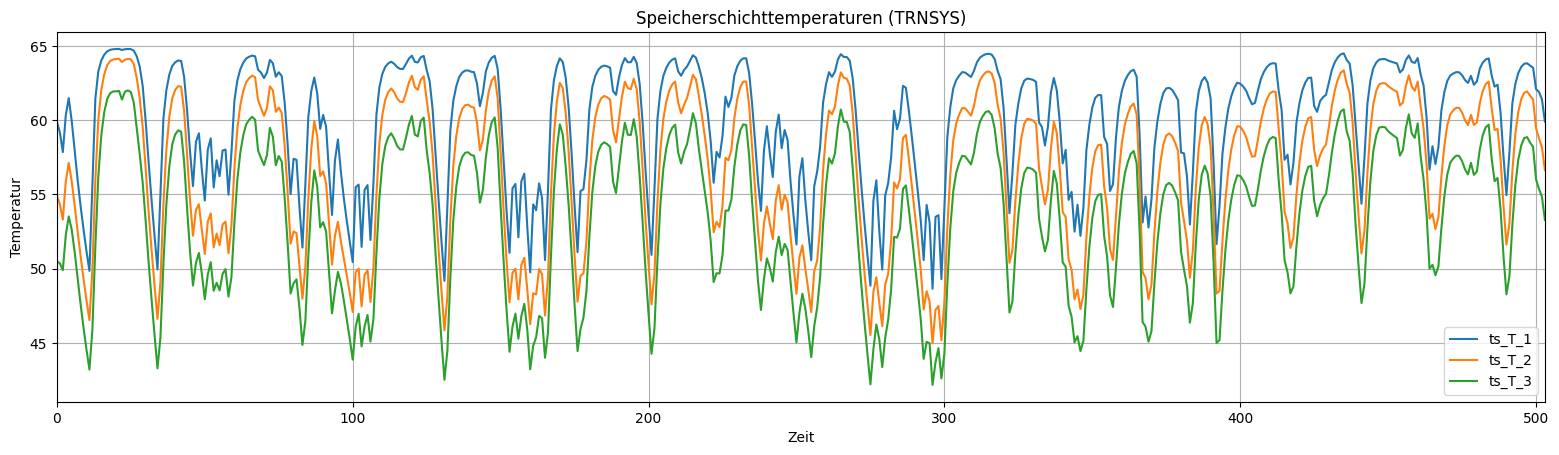

In [19]:
TRNSYS_T_s = TRNSYSdata3weeks[['ts_T_1', 'ts_T_2', 'ts_T_3']].copy()
TRNSYS_T_s.plot(figsize=(19.2, 4.8))

plt.title('Speicherschichttemperaturen (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 503)
plt.grid()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/ts_speicherschichten - 3 Wochen.png')
plt.show()

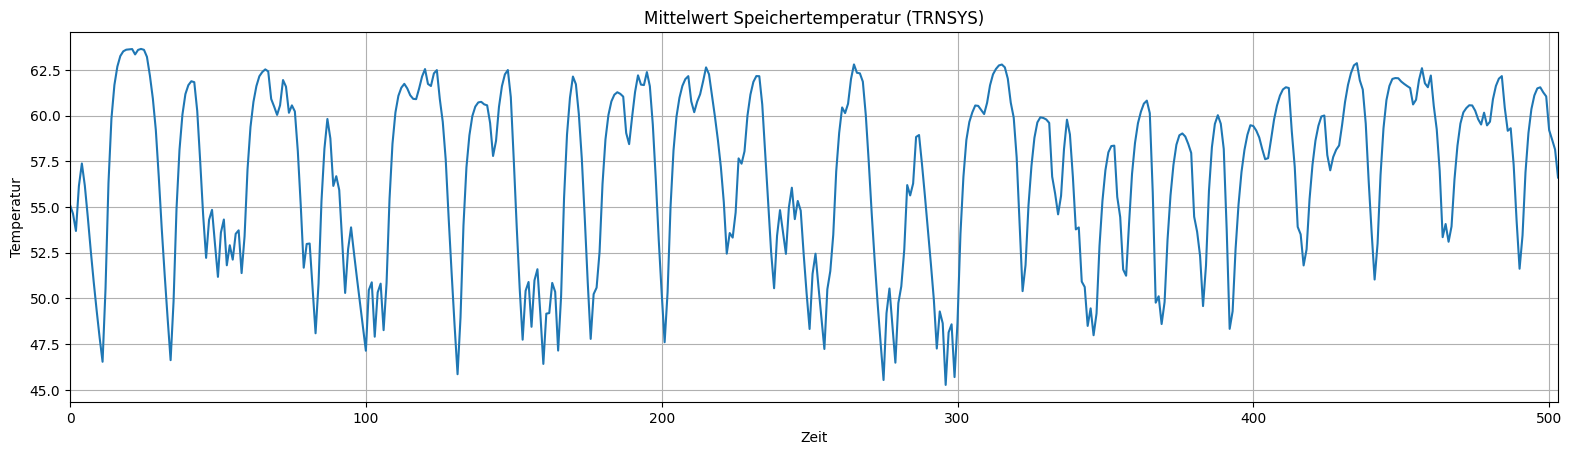

In [20]:
TRNSYS_T_m = TRNSYSdata3weeks['ts_T_m'].copy()
TRNSYS_T_m.plot(figsize=(19.2, 4.8))

plt.title('Mittelwert Speichertemperatur (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 503)
plt.grid()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/ts_speicherschichten_m - 3 Wochen.png')
plt.show()

# CSV-Ausgabe

In [21]:
# Kombinierten DataFrame erstellen
output_pypsa = pd.DataFrame({
    'py_P_elec': p_elec.values.flatten(),
    'py_P_heat': p_heat.values.flatten(),
    'py_m_flow': m_flow.values.flatten(),
    'py_COP': COP.values.flatten(),
    'py_status': status.values.flatten(),
    'py_T_1': heatstore_daten['hs'][1].values.flatten(),
    'py_T_2': heatstore_daten['hs'][2].values.flatten(),
    'py_T_3': heatstore_daten['hs'][3].values.flatten(),
    'py_T_m': hs_m.values.flatten(),
})
output_pypsa = output_pypsa.round(6)

output_pypsa.to_csv(
    "Outputs/konstanterVolumenspeicher - 3 Wochen/output_pypsa_3_weeks.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)

In [22]:
output_combined = pd.concat([output_pypsa, TRNSYSdata3weeks], axis=1)
output_combined

,py_P_elec,py_P_heat,py_m_flow,py_COP,py_status,py_T_1,py_T_2,py_T_3,py_T_m,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_T_1,ts_T_2,ts_T_3,ts_P_heat,ts_m_flow
0,6.177112,11.612970,700.0,1.88,1.0,60.092165,55.196377,50.715416,55.334653,0.0,146.376469,6.286,1.7,49.884832,55.109029,59.884832,54.914720,50.527535,11.613,700.0
1,0.000000,0.000000,-0.0,1.86,-0.0,58.807053,54.144400,50.307946,54.419800,1.0,146.376469,5.997,1.7,49.186820,54.631609,59.186820,54.343935,50.364073,0.000,0.0
2,0.000000,0.000000,-0.0,1.85,-0.0,57.527322,53.141119,49.684955,53.451132,2.0,154.986841,5.705,1.8,47.854299,53.688414,57.854299,53.305893,49.905051,0.000,0.0
3,4.973682,9.151576,700.0,1.84,1.0,61.297298,57.343202,53.743065,57.461188,3.0,146.376469,5.534,1.7,50.313022,56.148858,60.313022,55.871691,52.261861,9.152,700.0
4,0.000000,0.000000,-0.0,1.84,-0.0,60.180563,56.353020,52.943978,56.492520,4.0,154.986841,5.451,1.8,51.484057,57.377655,61.484057,57.127032,53.521878,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,3.924586,5.612158,700.0,1.43,1.0,63.481525,61.290182,58.096741,60.956149,499.0,499.402073,-4.842,5.8,53.538959,61.046521,63.538959,61.396121,58.204483,5.612,700.0
500,0.000000,0.000000,-0.0,1.40,-0.0,60.854789,58.053061,54.596809,57.834886,500.0,499.402073,-5.690,5.8,52.092700,59.197769,62.092700,59.474374,56.026234,0.000,0.0
501,5.454546,7.581819,700.0,1.39,1.0,62.025204,59.005046,55.673950,58.901400,501.0,482.181288,-6.235,5.6,51.896338,58.683329,61.896338,58.782158,55.371491,7.582,700.0
502,0.000000,0.000000,-0.0,1.38,-0.0,60.399230,57.258983,53.879758,57.179324,502.0,275.532173,-6.605,3.2,51.402280,58.143167,61.402280,58.178004,54.849217,0.000,0.0


In [23]:
output_combined_ordered = output_combined.iloc[:, [11, 10, 9, 12, 0, 3, 4, 1, 18, 2, 19, 5, 15, 6, 16, 7, 17, 8, 14, 13, 12]]
output_combined_ordered.to_csv(
    "Outputs/konstanterVolumenspeicher - 3 Wochen/output_combined_ordered - 3 Wochen.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)
output_combined_ordered

,ts_T_amb,ts_m_heatspace,Time,ts_P_heatspace,py_P_elec,py_COP,py_status,py_P_heat,ts_P_heat,py_m_flow,...,py_T_1,ts_T_1,py_T_2,ts_T_2,py_T_3,ts_T_3,py_T_m,ts_T_m,ts_T_R,ts_P_heatspace
0,6.286,146.376469,0.0,1.7,6.177112,1.88,1.0,11.612970,11.613,700.0,...,60.092165,59.884832,55.196377,54.914720,50.715416,50.527535,55.334653,55.109029,49.884832,1.7
1,5.997,146.376469,1.0,1.7,0.000000,1.86,-0.0,0.000000,0.000,-0.0,...,58.807053,59.186820,54.144400,54.343935,50.307946,50.364073,54.419800,54.631609,49.186820,1.7
2,5.705,154.986841,2.0,1.8,0.000000,1.85,-0.0,0.000000,0.000,-0.0,...,57.527322,57.854299,53.141119,53.305893,49.684955,49.905051,53.451132,53.688414,47.854299,1.8
3,5.534,146.376469,3.0,1.7,4.973682,1.84,1.0,9.151576,9.152,700.0,...,61.297298,60.313022,57.343202,55.871691,53.743065,52.261861,57.461188,56.148858,50.313022,1.7
4,5.451,154.986841,4.0,1.8,0.000000,1.84,-0.0,0.000000,0.000,-0.0,...,60.180563,61.484057,56.353020,57.127032,52.943978,53.521878,56.492520,57.377655,51.484057,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,-4.842,499.402073,499.0,5.8,3.924586,1.43,1.0,5.612158,5.612,700.0,...,63.481525,63.538959,61.290182,61.396121,58.096741,58.204483,60.956149,61.046521,53.538959,5.8
500,-5.690,499.402073,500.0,5.8,0.000000,1.40,-0.0,0.000000,0.000,-0.0,...,60.854789,62.092700,58.053061,59.474374,54.596809,56.026234,57.834886,59.197769,52.092700,5.8
501,-6.235,482.181288,501.0,5.6,5.454546,1.39,1.0,7.581819,7.582,700.0,...,62.025204,61.896338,59.005046,58.782158,55.673950,55.371491,58.901400,58.683329,51.896338,5.6
502,-6.605,275.532173,502.0,3.2,0.000000,1.38,-0.0,0.000000,0.000,-0.0,...,60.399230,61.402280,57.258983,58.178004,53.879758,54.849217,57.179324,58.143167,51.402280,3.2


# Combined Plots

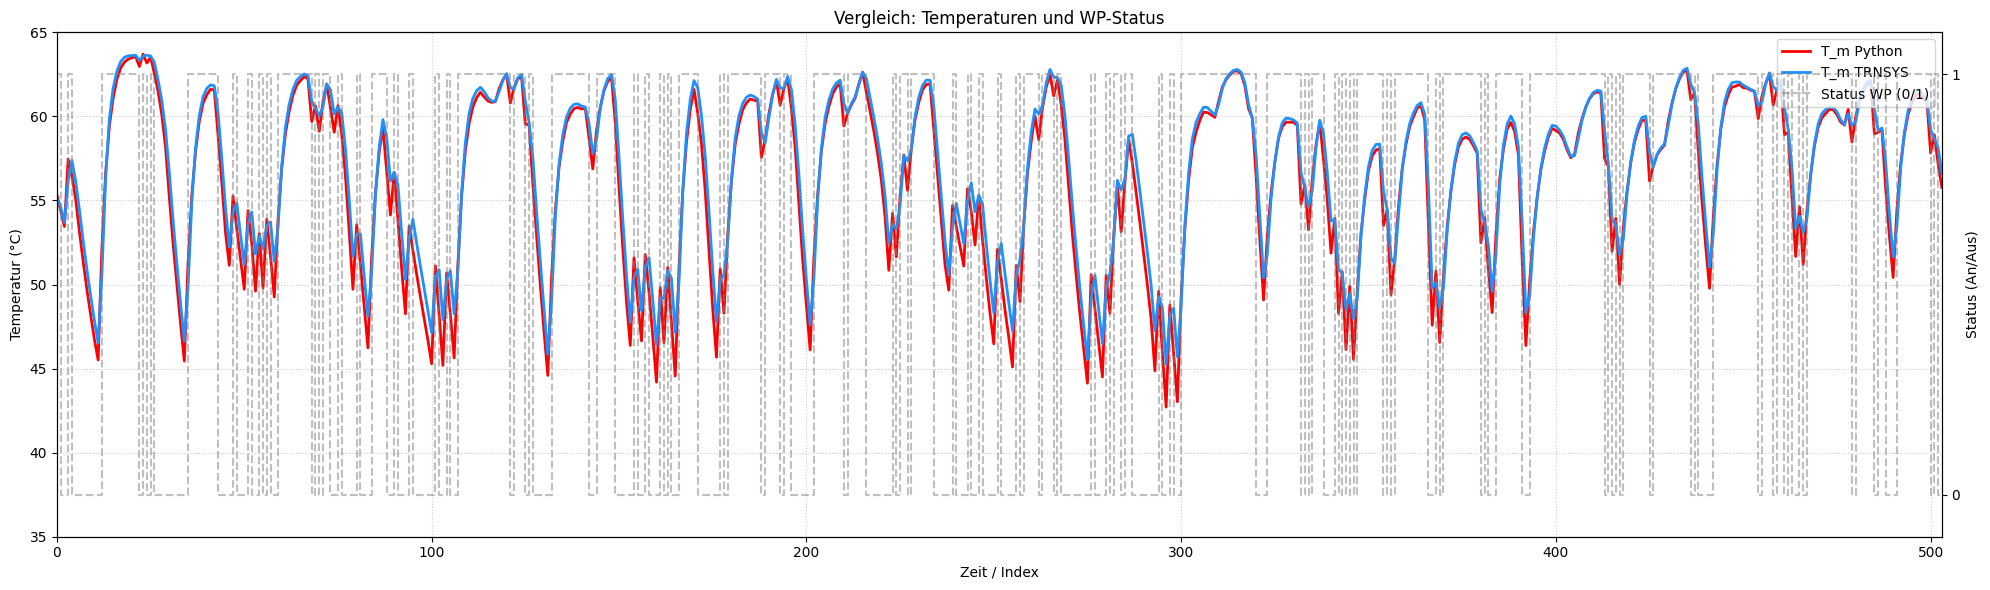

In [24]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(20, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=2, color='red')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_m'], label='T_m TRNSYS', linewidth=2, color='dodgerblue')

ax1.set_title('Vergleich: Temperaturen und WP-Status')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 503)
ax1.set_ylim(35, 65) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Rechte y-Achse: WP Status (0 oder 1) ---
ax2 = ax1.twinx()
# drawstyle='steps-post' macht den An/Aus-Charakter deutlich
ax2.plot(output_pypsa.index, output_pypsa['py_status'], 
         label='Status WP (0/1)', color='grey', linestyle='--', drawstyle='steps-post', alpha=0.5)

ax2.set_ylabel('Status (An/Aus)')
ax2.set_ylim(-0.1, 1.1) # Etwas Puffer nach oben/unten, damit man die Linie besser sieht
ax2.set_yticks([0, 1])  # Nur 0 und 1 anzeigen

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/vergleich_T_m+status - 3 Wochen.png')
plt.show()

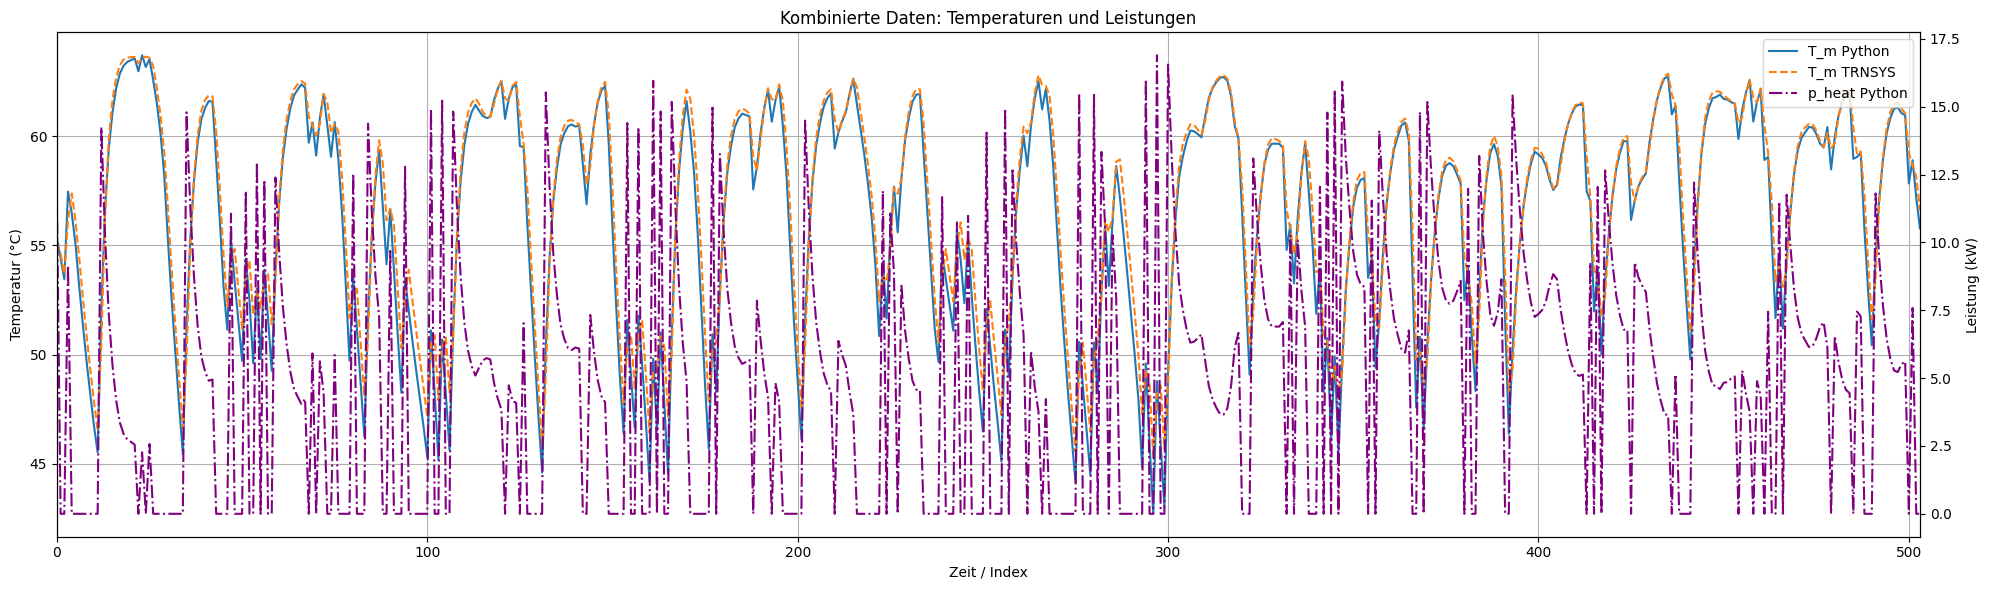

In [25]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(20, 6))

# Plotten der Temperaturen beider Datenquellen auf ax1
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=1.5)
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_m'], label='T_m TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Kombinierte Daten: Temperaturen und Leistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 503)
ax1.grid(True)

# Rechte y-Achse: Leistungen (in kW)
ax2 = ax1.twinx()

# Plotten der Leistungen aus output_pypsa
ax2.plot(output_pypsa.index, output_pypsa['py_P_heat'], label='p_heat Python', color='purple', linestyle='-.', linewidth=1.5)
# Optional: Falls TRNSYS Leistung auch geplottet werden soll (Spaltenname p_heat laut deinem CSV-Beispiel)
if 'p_heat' in TRNSYSdata3weeks.columns:
    ax2.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_p_heat'], label='p_heat TRNSYS', color='red', linestyle=':', linewidth=1.5)

ax2.set_ylabel('Leistung (kW)')

# Legende für beide Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/vergleich_T_m+p_heat - 3 Wochen.png')
plt.show()

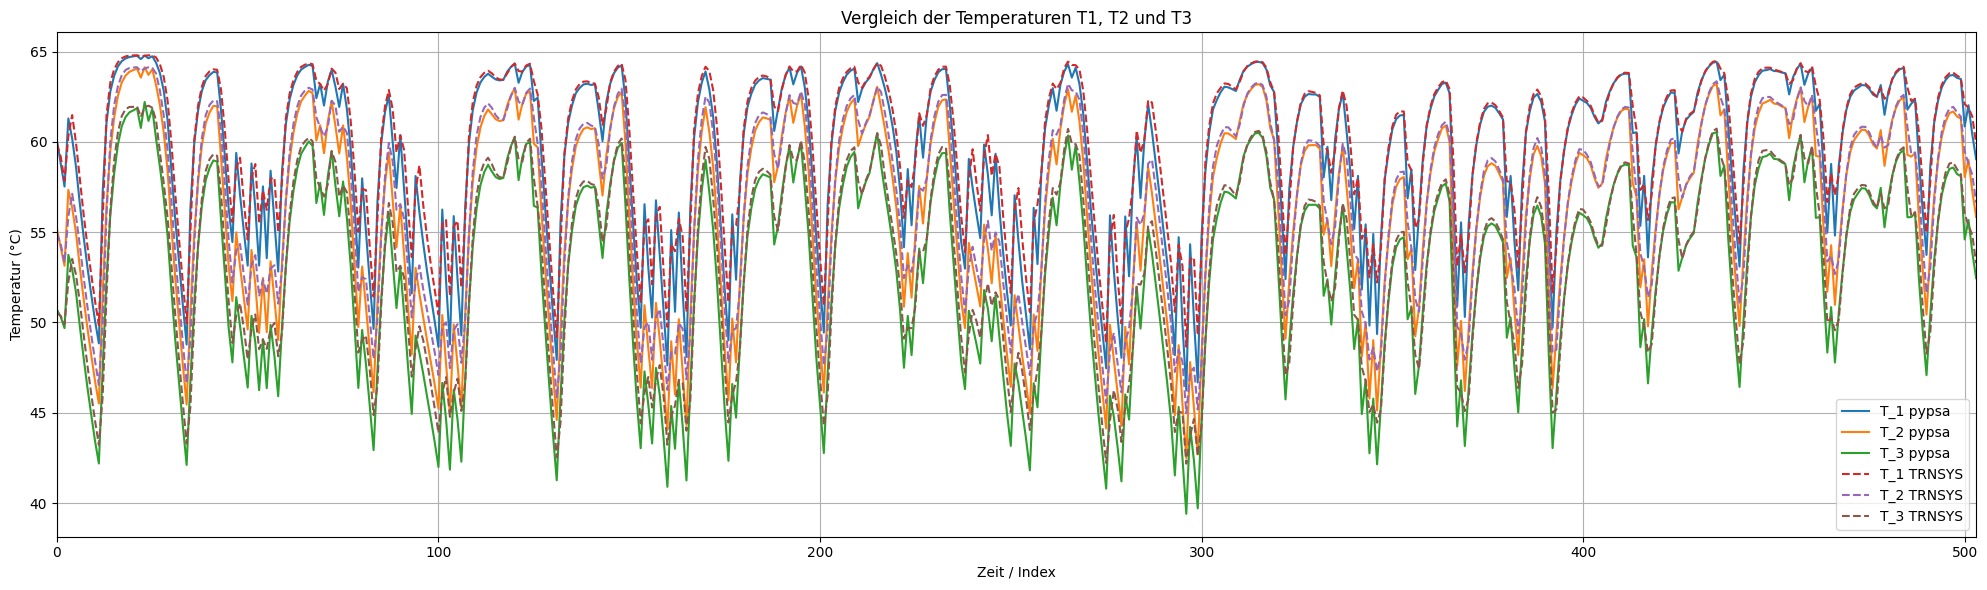

In [26]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(20, 6))

# Plotten der Temperaturen T1, T2 und T3
# Python Daten
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5)

# TRNSYS Daten (gestrichelt für bessere Unterscheidung)
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 503)
ax1.grid(True)
ax1.legend() # Fügt die Legende hinzu, um die Linien zu unterscheiden

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Vergleich der Temperaturen T1, T2 und T3 - 3 Wochen.png')
plt.show()


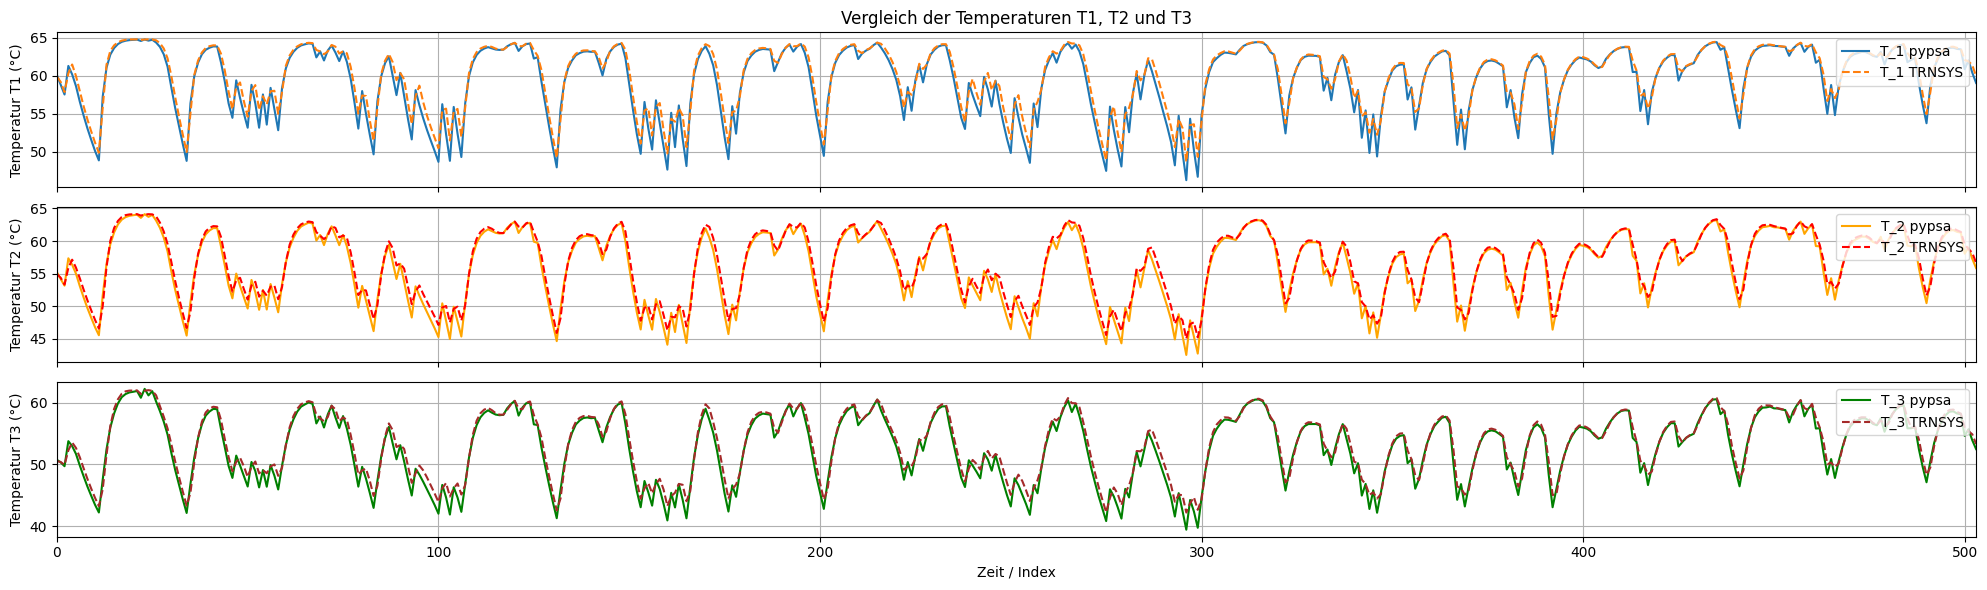

In [27]:
# sharex=True sorgt dafür, dass die X-Achse für alle Plots gleich ist
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 6), sharex=True)

# --- Plot für T1 ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.set_ylabel('Temperatur T1 (°C)')
ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.grid(True)
ax1.legend(loc='upper right')

# --- Plot für T2 ---
ax2.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5, color='orange')
ax2.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--', color='red')
ax2.set_ylabel('Temperatur T2 (°C)')
ax2.grid(True)
ax2.legend(loc='upper right')

# --- Plot für T3 ---
ax3.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5, color='green')
ax3.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--', color='brown')
ax3.set_ylabel('Temperatur T3 (°C)')
ax3.set_xlabel('Zeit / Index')
ax3.set_xlim(0, 503)
ax3.grid(True)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Vergleich der Temperaturen T1, T2 und T3 - 3 Wochen - einzelne Grafiken.png')
plt.show()

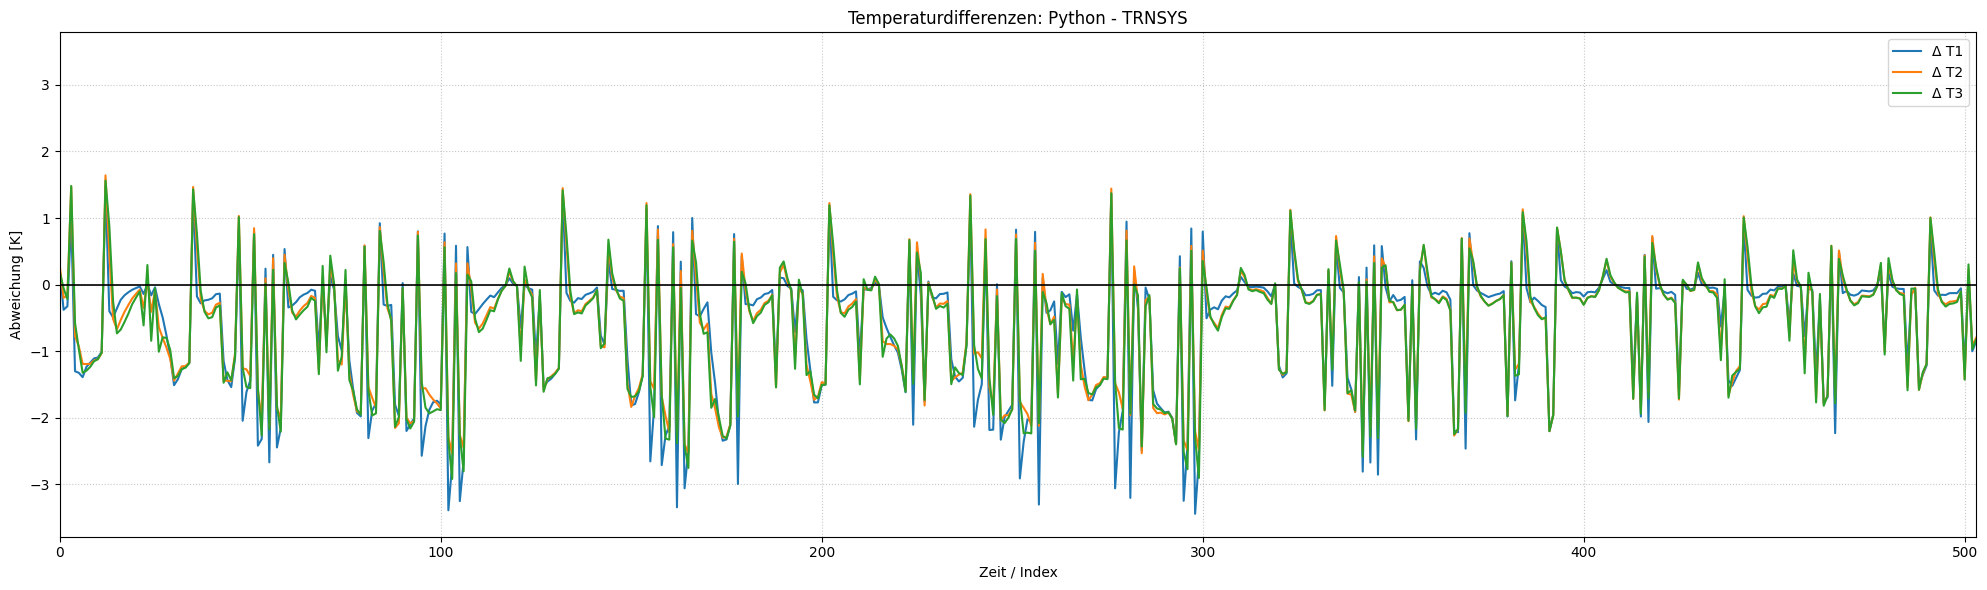

In [28]:
# Berechnung der Differenzen (Python - TRNSYS)
delta_T_1 = output_pypsa['py_T_1'] - TRNSYSdata3weeks['ts_T_1']
delta_T_2 = output_pypsa['py_T_2'] - TRNSYSdata3weeks['ts_T_2']
delta_T_3 = output_pypsa['py_T_3'] - TRNSYSdata3weeks['ts_T_3']

# Erstelle Figur
fig, ax = plt.subplots(figsize=(20, 6))

# Plotten der Differenzen
ax.plot(output_pypsa.index, delta_T_1, label='Δ T1')
ax.plot(output_pypsa.index, delta_T_2, label='Δ T2')
ax.plot(output_pypsa.index, delta_T_3, label='Δ T3')

# Null-Linie als Referenz (Zentrum)
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

# Achseneinstellungen
ax.set_title('Temperaturdifferenzen: Python - TRNSYS')
ax.set_xlabel('Zeit / Index')
ax.set_ylabel('Abweichung [K]')
ax.set_xlim(0, 503)

# Symmetrische Y-Achse für Null in der Mitte
limit = max(abs(delta_T_1).max(), abs(delta_T_2).max(), abs(delta_T_3).max()) * 1.1
ax.set_ylim(-limit, limit)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()


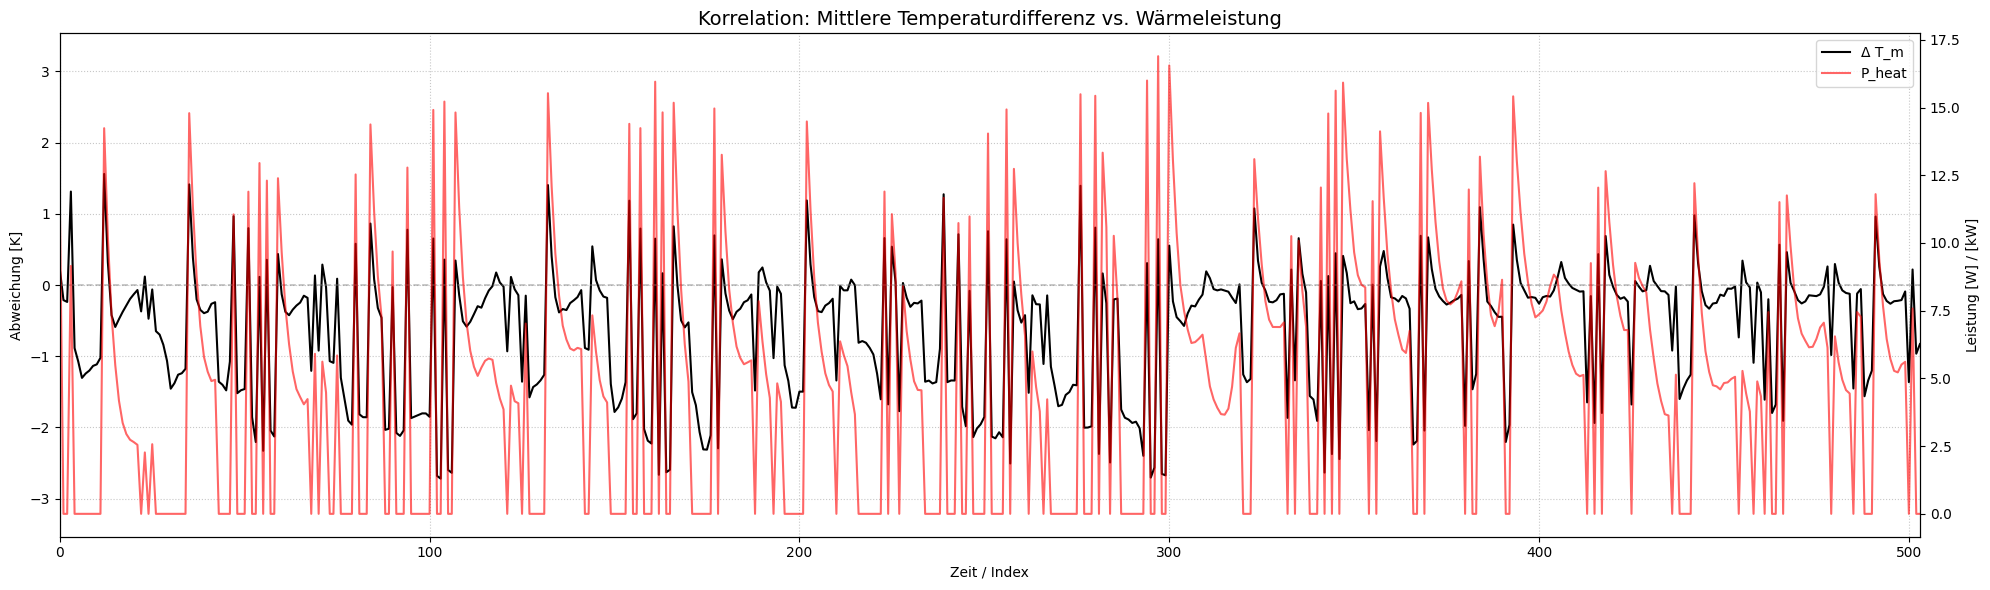

In [29]:
delta_T_m = output_pypsa['py_T_m'] - TRNSYSdata3weeks['ts_T_m']

fig, ax1 = plt.subplots(figsize=(20, 6))

ax1.plot(output_pypsa.index, delta_T_m, label='Δ T_m', color='black')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Abweichung [K]')
ax1.tick_params(axis='y')

ax1.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.5)

limit = abs(delta_T_m).max() * 1.3 if abs(delta_T_m).max() > 0 else 1
ax1.set_ylim(-limit, limit)

ax2 = ax1.twinx() 
ax2.plot(output_combined.index, output_combined.py_P_heat, label='P_heat', color='red', alpha=0.6)
ax2.set_ylabel('Leistung [W] / [kW]') 
ax2.tick_params(axis='y')

plt.title('Korrelation: Mittlere Temperaturdifferenz vs. Wärmeleistung', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlim(0, 503)
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Korrelation - Mittlere Temperaturdifferenz vs. Wärmeleistung - 3 Wochen.png')
plt.show()

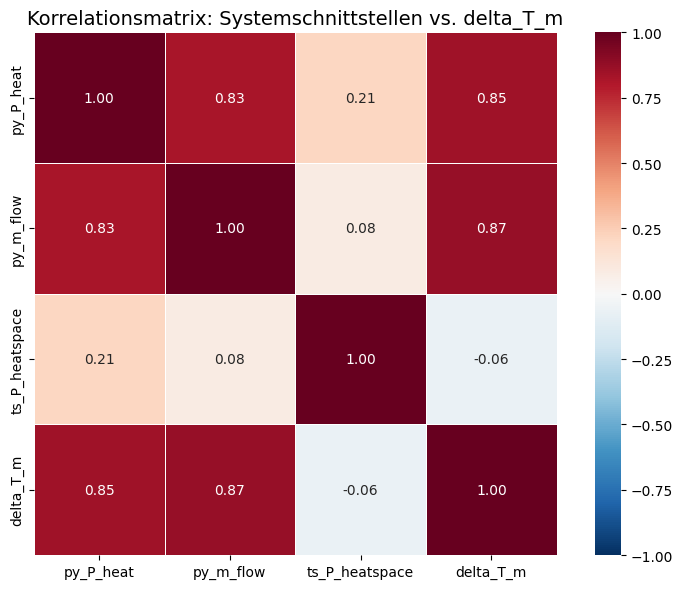

In [30]:
correlation_cols = [
    'py_P_heat', 
    'py_m_flow', 
    'ts_P_heatspace'
]

matrix_df = output_combined[correlation_cols].copy()
matrix_df['delta_T_m'] = delta_T_m

full_corr_matrix = matrix_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(full_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt='.2f',
            square=True,
            linewidths=.5)

plt.title('Korrelationsmatrix: Systemschnittstellen vs. delta_T_m', fontsize=14)
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Korrelationsmatrix Systemschnittstellen vs. delta_T_m - 3 Wochen.png')
plt.show()

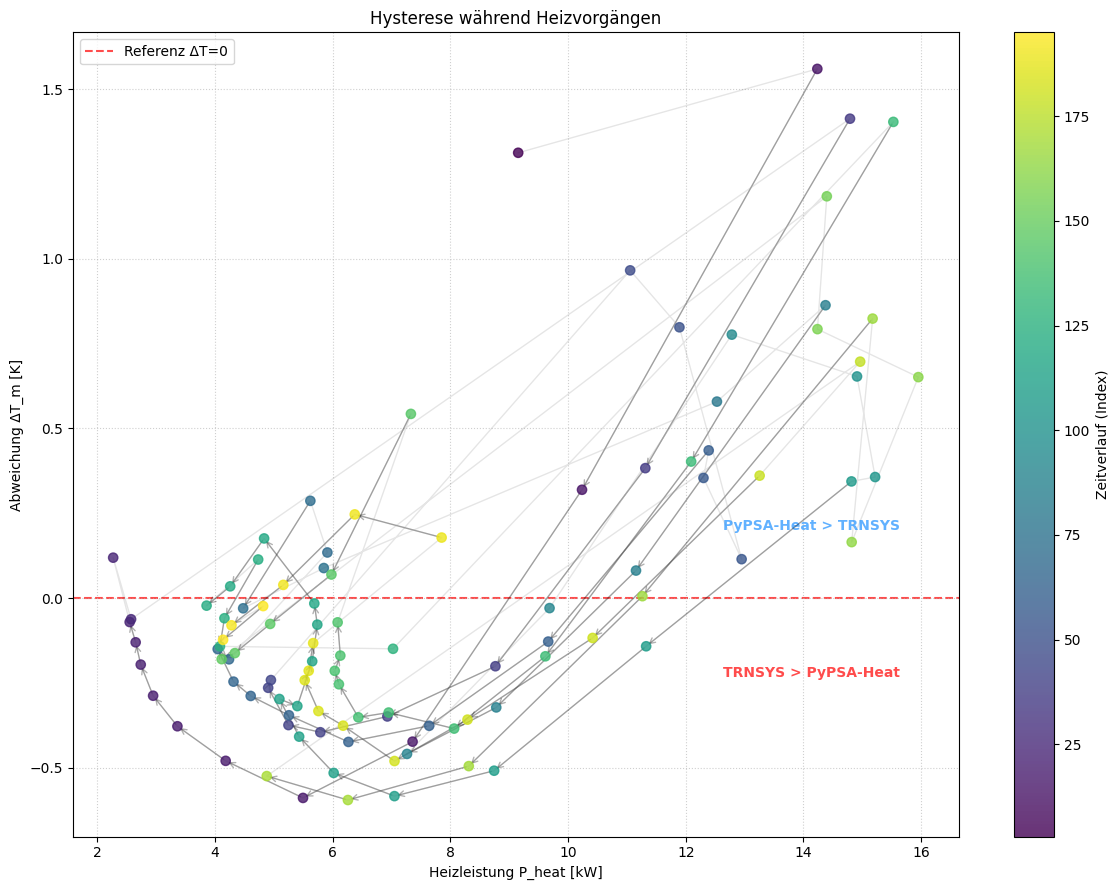

In [ ]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()

plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Referenz ΔT=0', zorder=1)

x_pos = plot_data_filtered['P_heat'].max() * 0.98
plt.text(x_pos, 0.2, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.7, ha='right')
plt.text(x_pos, -0.2, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.7, va='top', ha='right')

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysterese während Heizvorgängen')
plt.xlabel('Heizleistung P_heat [kW]')
plt.ylabel('Abweichung ΔT_m [K]')
plt.colorbar(scatter, label='Zeitverlauf (Index)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Hysterese während Heizvorgängen - 3 Wochen.png')
plt.tight_layout()
plt.show()

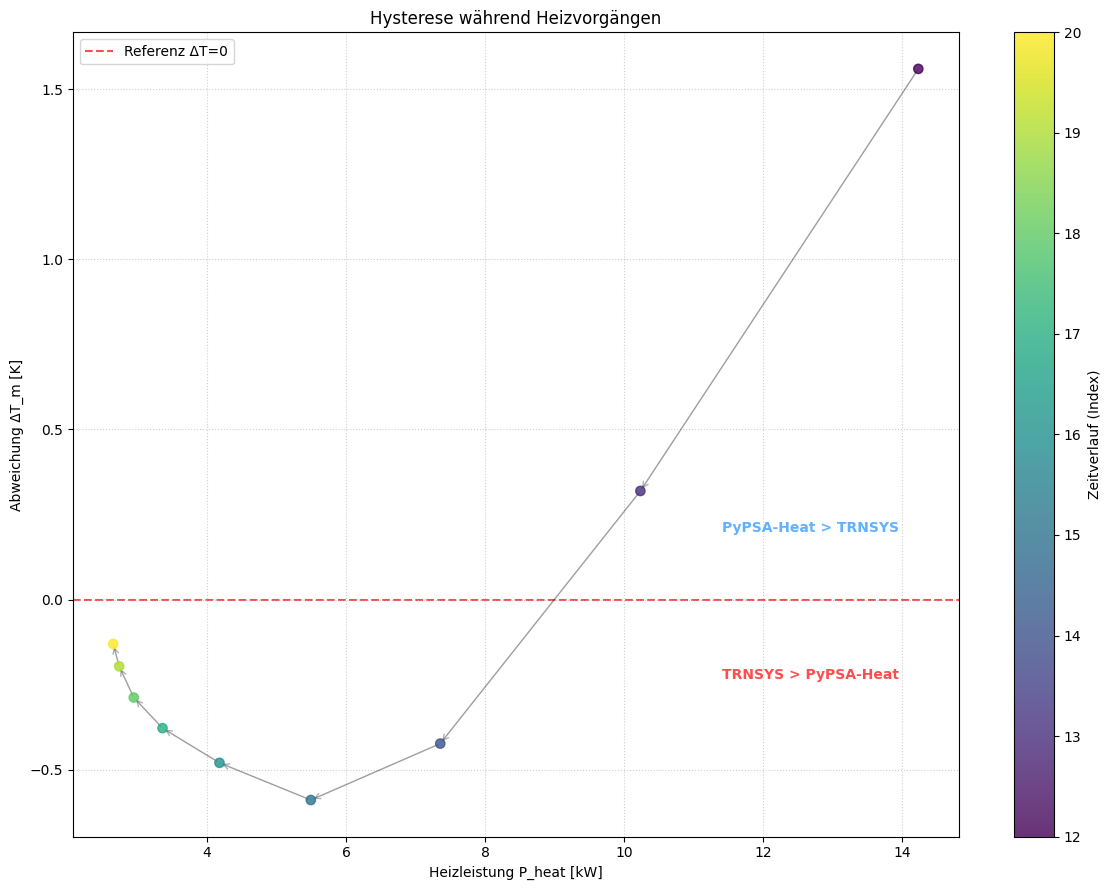

In [48]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()

plot_data = plot_data[(plot_data['index'] >= 5) & (plot_data['index'] <= 20)]

plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Referenz ΔT=0', zorder=1)

x_pos = plot_data_filtered['P_heat'].max() * 0.98
plt.text(x_pos, 0.2, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.7, ha='right')
plt.text(x_pos, -0.2, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.7, va='top', ha='right')

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysterese während Heizvorgängen')
plt.xlabel('Heizleistung P_heat [kW]')
plt.ylabel('Abweichung ΔT_m [K]')
plt.colorbar(scatter, label='Zeitverlauf (Index)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Hysterese während Heizvorgängen - 3 Wochen.png')
plt.tight_layout()
plt.show()

In [32]:
delta_T_m.sum()

-313.3416529999999